In [1]:
import os
import torch
from torch import nn
import pandas as pd

In [2]:
# 加载 autoreload 扩展插件
%load_ext autoreload

# 自动重载所有修改过的模块
%autoreload 2

In [3]:
# 未清理平行语句
OriDataDir = "./data/jpn.txt"

# 清理后储存位置
CleanedDataDir = "./data/cleaned.txt"
SecondPartData = "./data/日语-英语.tsv"
JaTokensFile = "./data/JaTokens.pkl"
EnTokensFile = "./data/EnTokens.pkl"

In [4]:
# 数据清理
def clean_data(input_file, output_file, min_len = 0, max_len = 200):
    cleaned = []

    with open(input_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            parts = line.split("\t")

            if max_len > len(parts[1]) > min_len:
                cleaned.append(parts[1] + '\t' + parts[0])

    with open(output_file, "w", encoding="utf-8") as f:
        for line in cleaned:
            f.write(line + '\n')

    print("cleaned up")

# clean_data(OriDataDir, CleanedDataDir)


In [5]:
# 读入平行语录
Source = []
Target = []

# 读上方处理过的txt文件
with open(CleanedDataDir, "r", encoding = "utf-8") as f:
    for line in f:
        line = line.strip()
        parts = line.split('\t')
        Source.append(parts[0])
        Target.append(parts[1])


# 处理第二部分tsv文件, 分隔符为'\t'，把引号当成普通字符串处理
pd_tsv = pd.read_csv(SecondPartData, sep = "\t", quoting=3, header=None).fillna("")
SecondPartJA = pd_tsv.iloc[:, 1].tolist()
SecondPartEN = pd_tsv.iloc[:, 3].tolist()
Source = Source + SecondPartJA
Target = Target + SecondPartEN

print(len(Source))
print(len(Target))


393079
393079


In [6]:
# 日语分词,CPU密集任务，多进程跑。
# ipynb文件不易运行多进程，模块分离到 my_tokenize.py里


In [7]:
# pickle反序列化读取token
import pickle

JaTokens = pickle.load(open(JaTokensFile, "rb"))
EnTokens = pickle.load(open(EnTokensFile, "rb"))

print(len(JaTokens))
print(len(EnTokens))

print(JaTokens[-10:])
print(EnTokens[-10:])


393079
393079
[['夕暮れ', 'の', '商店', '街', 'を', '歩く', 'と', '、', 'どこ', 'か', '懐かしい', '気持ち', 'に', 'なる', '。'], ['この', '作家', 'の', '文体', 'は', '独特', 'で', '、', '一度', '読ん', 'だら', '忘れ', 'られ', 'ない', '。'], ['技術', 'が', '追いつく', 'まで', 'に', '5', '年', 'は', 'かかる', 'だろ', 'う', '。'], ['しかし', '生存', '者', '達', 'は', '、', 'その', '事実', 'を', '知ら', 'なかっ', 'た', '。'], ['物理', '学', 'は', '難しい', 'です', '。'], ['物理', 'は', '難しい', '。'], ['映画', '館', 'に', '行か', 'なかっ', 'た', 'よ', '。'], ['アメリカ', 'で', '行わ', 'れ', 'た', '全国', '的', 'な', '世論', '調査', 'に', 'よる', 'と', '、', 'イスラム', '教徒', 'が', 'テロリズム', 'と', '関連', 'し', 'て', 'いる', 'という', '考え', 'が', '広く', '浸透', 'し', 'て', 'いる', '。'], ['彼女', 'は', 'ネコ', 'が', '大好き', 'だ', '。'], ['説明', 'に', 'なっ', 'て', 'なく', 'ね', '？']]
[['There', "'s", 'something', 'nostalgic', 'about', 'walking', 'the', 'shopping', 'district', 'in', 'the', 'evening', '.'], ['This', 'author', "'s", 'writing', 'style', 'is', 'unique', ';', 'once', 'you', 'read', 'it', ',', 'you', "'ll", 'never', 'forget', '.'], ['It', 'must', 'be', 'five',

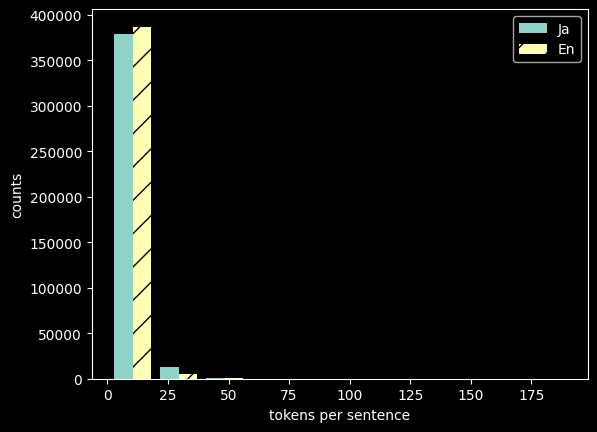

In [8]:
# 绘制每个文本包含的词元数量图
import matplotlib.pyplot as plt

def block(xlist, ylist, xlabel, ylabel, legend):


    plt.xlabel(xlabel)
    plt.ylabel(ylabel)


    # plt.hist() 返回一个元组 (n, bins, patches)。
    # n: 每个 bin 中的数据量（数值）。
    # bins: 长方形的数值边界。
    # patches: 直方图的条形对象，这是我们需要的。
    # label 参数用于指定图例。
    _,__, patches = plt.hist([xlist, ylist],label = legend)
    for patch in patches[1]:
        patch.set_hatch('/')

    plt.legend()
    plt.show()

JaLenPerSentence = [len(s) for s in JaTokens]
EnLenPerSentence = [len(s) for s in EnTokens]

block(
    JaLenPerSentence,
    EnLenPerSentence,
    "tokens per sentence",
    "counts",
    ["Ja","En"]
)


In [14]:
from transformer_parts.vocab import Vocabulary

JaVocab = Vocabulary(JaTokens, min_freq= 1, reserved_tokens= ["<pad>","<bos>","<eos>"])
EnVocab = Vocabulary(EnTokens, min_freq= 1, reserved_tokens= ["<pad>","<bos>","<eos>"])

print(len(JaVocab))
print(len(EnVocab))

38784
32003
